# 03 - GraphSAGE Training
Hamilton et al. (2017)
Porównanie z GCN i GAT przy różnych progach etykiet na datasecie Cora

In [10]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import SAGEConv

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]
original_train_mask = data.train_mask.clone()

print(f'Węzły:    {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Klasy:    {dataset.num_classes}')

Węzły:    2708
Krawędzie: 10556
Klasy:    7


## Wczytanie wyników GCN i GAT

In [11]:
with open('../models/gcn_results.json') as f:
    gcn_results = {float(k): v for k, v in json.load(f).items()}

with open('../models/gat_results.json') as f:
    gat_results = {float(k): v for k, v in json.load(f).items()}

ratios = [0.05, 0.10, 0.20]
seeds  = [42, 123, 456, 789, 1000]
labels = ['5%', '10%', '20%']

print('Wyniki wczytane:')
print(f'{"Model":<10} {"5%":>12} {"10%":>12} {"20%":>12}')
print('-' * 50)
for name, res in [('GCN', gcn_results), ('GAT', gat_results)]:
    row = f'{name:<10}'
    for ratio in ratios:
        row += f'  {np.mean(res[ratio]):.4f}±{np.std(res[ratio]):.4f}'
    print(row)

Wyniki wczytane:
Model                5%          10%          20%
--------------------------------------------------
GCN         0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT         0.8058±0.0090  0.8208±0.0087  0.8448±0.0102


## Funkcje pomocnicze
Takie jak w poprzednich notebookach

In [12]:
def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)

    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]

    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True

    return train_mask

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

## Architektura GraphSAGE
Hamilton et al. (2017) - próbkowanie sąsiadów zamiast agregacji wszystkich.
Pozwala skalować się na duże grafy i działa indukcyjnie (widzi nowe węzły bez retrainingu)
Benchmark w oryginalnym paperze: skupienie na skalowaniu, nie na accuracy przy małych danych.

In [13]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

## Baseline - standardowy split Planetoid
Odtworzenie wyników na oryginalnym podziale - punkt odniesienia do papieru Hamilton et al. (2017).

In [14]:
data.train_mask = original_train_mask

baseline_model = GraphSAGE(dataset.num_features, 64, dataset.num_classes)
baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(200):
    loss = train(baseline_model, baseline_optimizer)
    if epoch % 20 == 0:
        acc = test(baseline_model)
        print(f'Epoch {epoch:3d}: Loss={loss:.4f}, Acc={acc:.4f}')

baseline_acc = test(baseline_model)
print(f'\nBaseline GraphSAGE (paper split): {baseline_acc:.4f}')
print(f'Paper (Hamilton 2017): 0.812')

Epoch   0: Loss=1.9450, Acc=0.5010
Epoch  20: Loss=0.0025, Acc=0.7870
Epoch  40: Loss=0.0021, Acc=0.7820
Epoch  60: Loss=0.0028, Acc=0.7870
Epoch  80: Loss=0.0039, Acc=0.8090
Epoch 100: Loss=0.0041, Acc=0.7980
Epoch 120: Loss=0.0044, Acc=0.7940
Epoch 140: Loss=0.0039, Acc=0.8010
Epoch 160: Loss=0.0037, Acc=0.8080
Epoch 180: Loss=0.0034, Acc=0.7970

Baseline GraphSAGE (paper split): 0.8000
Paper (Hamilton 2017): 0.812


## Eksperymenty - accuracy vs liczba etykiet

In [15]:
sage_results = defaultdict(list)
best_acc = 0

for ratio in ratios:
    for seed in seeds:
        data.train_mask = create_split(data, ratio, seed)

        model = GraphSAGE(dataset.num_features, 64, dataset.num_classes)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=0.01, weight_decay=5e-4)

        for epoch in range(200):
            train(model, optimizer)

        acc = test(model)
        sage_results[ratio].append(acc)
        print(f'SAGE | Ratio: {ratio:.0%}, Seed: {seed}, Acc: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), '../models/sage_best.pt')

data.train_mask = original_train_mask

print('\n--- Podsumowanie GraphSAGE ---')
for ratio, accs in sage_results.items():
    print(f'{ratio:.0%}: {np.mean(accs):.4f} ± {np.std(accs):.4f}')
print(f'Najlepszy model: {best_acc:.4f}')

SAGE | Ratio: 5%, Seed: 42, Acc: 0.7760
SAGE | Ratio: 5%, Seed: 123, Acc: 0.7980
SAGE | Ratio: 5%, Seed: 456, Acc: 0.7990
SAGE | Ratio: 5%, Seed: 789, Acc: 0.8120
SAGE | Ratio: 5%, Seed: 1000, Acc: 0.7910
SAGE | Ratio: 10%, Seed: 42, Acc: 0.8330
SAGE | Ratio: 10%, Seed: 123, Acc: 0.8030
SAGE | Ratio: 10%, Seed: 456, Acc: 0.8290
SAGE | Ratio: 10%, Seed: 789, Acc: 0.8250
SAGE | Ratio: 10%, Seed: 1000, Acc: 0.8190
SAGE | Ratio: 20%, Seed: 42, Acc: 0.8630
SAGE | Ratio: 20%, Seed: 123, Acc: 0.8280
SAGE | Ratio: 20%, Seed: 456, Acc: 0.8520
SAGE | Ratio: 20%, Seed: 789, Acc: 0.8210
SAGE | Ratio: 20%, Seed: 1000, Acc: 0.8480

--- Podsumowanie GraphSAGE ---
5%: 0.7952 ± 0.0118
10%: 0.8218 ± 0.0105
20%: 0.8424 ± 0.0156
Najlepszy model: 0.8630


## Porównanie wszystkich trzech modeli

In [16]:
all_results = {
    'GCN':       gcn_results,
    'GAT':       gat_results,
    'GraphSAGE': dict(sage_results),
}

print(f'{"Model":<12} {"5%":>14} {"10%":>14} {"20%":>14}')
print('-' * 58)
for name, res in all_results.items():
    row = f'{name:<12}'
    for ratio in ratios:
        row += f'  {np.mean(res[ratio]):.4f}±{np.std(res[ratio]):.4f}'
    print(row)

print('\n--- Różnica względem GCN ---')
for name in ['GAT', 'GraphSAGE']:
    print(f'\n{name}:')
    for ratio in ratios:
        diff = np.mean(all_results[name][ratio]) - np.mean(gcn_results[ratio])
        sign = '+' if diff >= 0 else ''
        print(f'  {ratio:.0%}: {sign}{diff:.4f}')

Model                    5%            10%            20%
----------------------------------------------------------
GCN           0.7922±0.0147  0.8152±0.0143  0.8274±0.0147
GAT           0.8058±0.0090  0.8208±0.0087  0.8448±0.0102
GraphSAGE     0.7952±0.0118  0.8218±0.0105  0.8424±0.0156

--- Różnica względem GCN ---

GAT:
  5%: +0.0136
  10%: +0.0056
  20%: +0.0174

GraphSAGE:
  5%: +0.0030
  10%: +0.0066
  20%: +0.0150


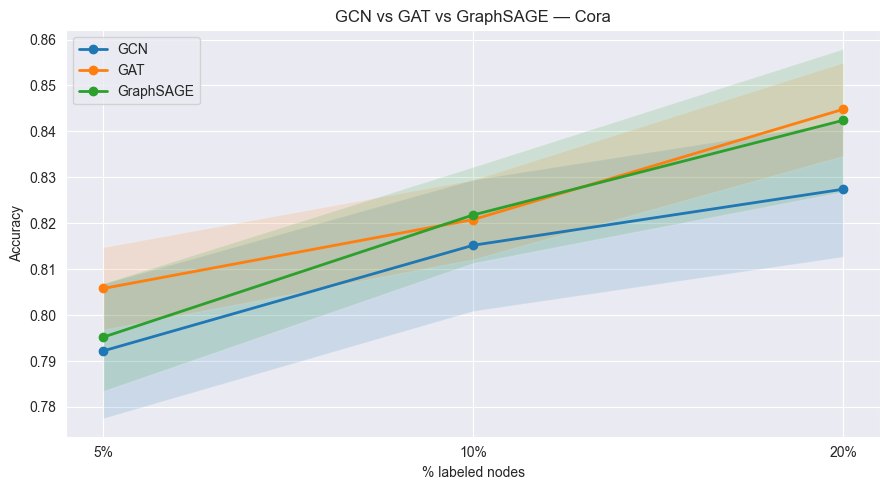

Wykres zapisany: ../results/all_models_comparison.png


In [17]:
plt.figure(figsize=(9, 5))
for name, res in all_results.items():
    means = [np.mean(res[r]) for r in ratios]
    stds  = [np.std(res[r])  for r in ratios]
    plt.plot(labels, means, marker='o', linewidth=2, label=name)
    plt.fill_between(labels,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.15)

plt.xlabel('% labeled nodes')
plt.ylabel('Accuracy')
plt.title('GCN vs GAT vs GraphSAGE — Cora')
plt.legend()
plt.tight_layout()
plt.savefig('../results/all_models_comparison.png')
plt.show()
print('Wykres zapisany: ../results/all_models_comparison.png')

In [18]:
with open('../models/sage_results.json', 'w') as f:
    json.dump({str(k): v for k, v in sage_results.items()}, f, indent=2)

all_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in all_results.items()
}
with open('../models/all_results.json', 'w') as f:
    json.dump(all_serializable, f, indent=2)

print('Zapisano:')
print('../models/sage_results.json')
print('../models/sage_best.pt')
print('../models/all_results.json  (zaktualizowany)')
print('../results/all_models_comparison.png')

Zapisano:
../models/sage_results.json
../models/sage_best.pt
../models/all_results.json  (zaktualizowany)
../results/all_models_comparison.png
